In [1]:
#%% add SPU UND and DCM IP address where the IOC is running to the enviroment variables
# SPU:A:DCM01 ip:    10.33.34.32:5064
# SPU:A:BASLER02 ip: 10.33.34.29:45649
# SPU:A:WBS01 ip:     10.39.50.76:33009 (FOE and WBS1 SLITS)

import os
os.environ['EPICS_CA_ADDR_LIST'] = '10.33.34.32 10.33.34.29 10.39.50.76 10.0.38.59'
print(os.environ['EPICS_CA_ADDR_LIST']) 

10.33.34.32 10.33.34.29 10.39.50.76 10.0.38.59


In [2]:
# import epics

import numpy as np
import matplotlib.pyplot as plt
import time
import apu
from scipy import constants
from dvf import DVF, HDFfile
from apu import initialize_apu, get_phase_from_energy
from hddcm import DCM
from slit import WBS1, FOES
import pandas as pd
import epics
from siriuspy.devices import SOFB

import h5py
# from scipy.optimize import curve_fit

PI = constants.pi
EMASS = constants.electron_mass
LSPEED = constants.speed_of_light
ECHARGE = constants.elementary_charge
PLANCK = constants.Planck/(2*PI)

In [3]:
und = apu.initialize_apu(beamline='SAPUCAIA')

In [4]:
epics.caget("SI-17SA:ID-APU22:Phase-Mon")

cannot connect to SI-17SA:ID-APU22:Phase-Mon


## 1. Make sure that the DVF is in position



In [35]:
slit = WBS1()

# slit.set_slits_ref()
# slit.set_slits_open()
slit.set_slits_closed()
# slit.set_slits_pos(-0.25)
# slit.set_left_pos(3.25+0.05)
# slit.set_bottom_pos(0.63-0.05)
# slit.set_right_pos(0.14-0.02)


In [42]:
foes = FOES()
foes.set_slits_ref()

## 2. Cofigure ROI

In [9]:
dvf = DVF()

In [29]:
roi_shape = (93, 110)
roi_start = (690, 565)

dvf.define_ROI(roi_shape, roi_start)

In [28]:
dvf.disable_ROI()

## 3. Define energy scan parameters

In [11]:
coefs = apu.get_sapucaia_poly_coefficients()
energy = apu.poly_any_degree(6.013, coefs)*3
energy

7.986616529607575

In [4]:
energy0 = 10 # keV
harmonic = 5


In [5]:
phase0 = get_phase_from_energy(19, 5, verbose=1)
print(phase0)

harmonic h = 5 is not valid for this energy.
please choose a valid harmonic number


possible harmonics for this energy are:
h = 7
h = 9
nan


/opt/mamba_files/mamba/envs/optics/repos/ER2LS/qt_window/apu.py:122: RuntimeWarning: invalid value encountered in sqrt
  k = np.sqrt(4*GAMMA**2*PLANCK*2*PI*LSPEED/(e1*1e3*ECHARGE*PERIOD)-2)


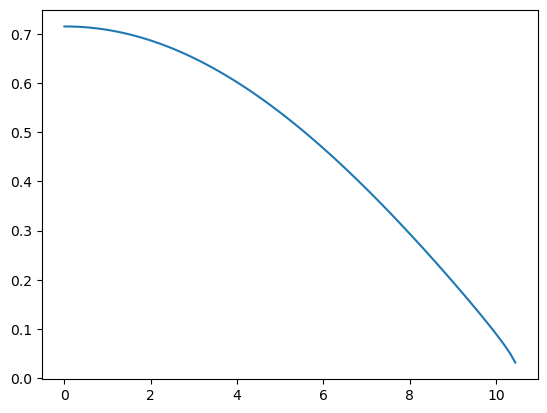

In [3]:
period = 22e-3
gamma = 5870
phases = np.linspace(0, 11, 101)
b = apu.calc_field(phases)
plt.plot(phases, b)

(1.0, 2.5)

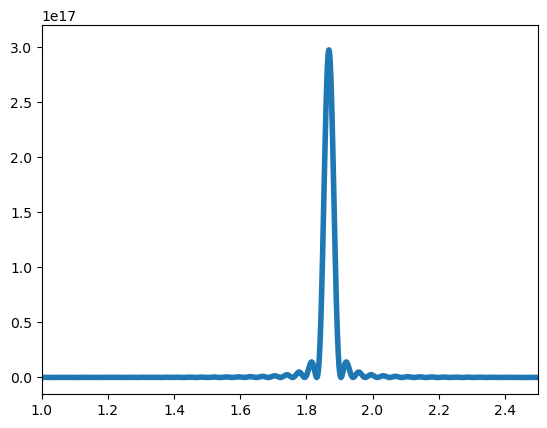

In [19]:
import undulator_radiation
energy, flux = undulator_radiation.calc_flux_density(b[0], 0)
max_harmonic = len(energy)
for n in np.arange(0, max_harmonic, 1):
    plt.plot(1e-3*energy[n], flux[n], color='C0', linewidth=4)
plt.xlim(1, 2.5)

Initialize Undulator

In [4]:
und = initialize_apu(beamline='SAPUCAIA')
time.sleep(1)
und.connected

True

In [14]:
und.phase_mon

2.5644296095848085

Initialize HD-DCM

In [18]:
dcm = DCM(timeout=5)

Move both DCM and UND to the target harmonic

In [4]:
phase0 = get_phase_from_energy(energy0, harmonic, verbose=1)
# und.cmd_move(kparam=phase0)

# und.cmd_move(kparam=5.419)


phase value is: 2.5647
energy: 10 keV
h = 5
fundamental energy = 2.0


possible harmonics for this energy are:
h = 3
h = 5


In [37]:
dcm.cmd_move_robust(energy0, timeout=5)


True

DVF: set exposure time

In [ ]:
if energy0 == 10.0:
    dvf.set_exposure_time(1.7e-3)

## 4. Run Measurement

Setup scan points

In [3]:
# fname_points = 'scan_points/h5_to_h7_open_slits.txt'
fname_points = 'h5_to_h7_open_slits.txt'

scanPoints = np.genfromtxt(fname_points)

labels = ['Energy [keV]', 'Phase [mm]', 'Exp. time [s]']
df = pd.DataFrame(scanPoints, columns=labels)
df

,Energy [keV],Phase [mm],Exp. time [s]
0,9.000,2.5647,0.0075
1,9.175,2.5647,0.0075
2,9.350,2.5647,0.0075
3,9.525,2.5647,0.0075
4,9.700,2.5647,0.0075
...,...,...,...
159,14.300,2.5647,0.0075
160,14.400,2.5647,0.0075
161,14.600,2.5647,0.0075
162,14.800,2.5647,0.0075


Text(0, 0.5, 'Exposure time [ms]')

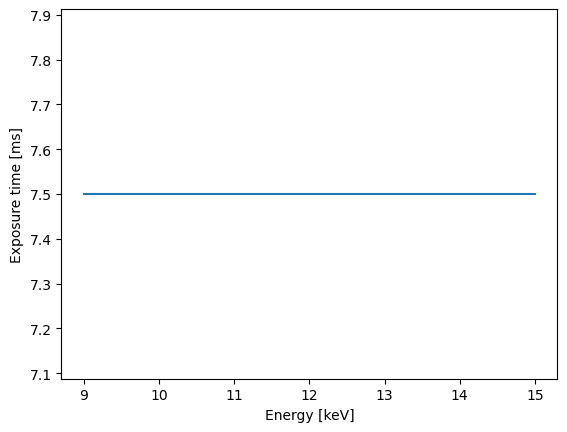

In [4]:
plt.figure()
plt.plot(scanPoints[:,0], scanPoints[:,2]*1e3)
plt.xlabel('Energy [keV]')
plt.ylabel('Exposure time [ms]')

Start Scan

In [11]:
folder = './'
fname_prefix = 'SPU_CS_eScan_{0:.1f}keV_h{1:d}_'.format(energy0, harmonic)


start_time = time.strftime("%Y-%m-%d_%H-%M-%S", time.localtime())

t0 = time.time()

hdf = HDFfile(filename=folder + fname_prefix + start_time + '.h5')
hdf.initialize_hdf5()

# move undulator to desired position
# und.cmd_move(kparam=phase0, timeout=5)
# time.sleep(3)
# phase_mon = und.phase_mon
# print('Undulator movement finished. Phase = {0:.3f}'.format(phase_mon))

ne = len(scanPoints)
for i in range(ne):
    
    print('Scanning energy point {0}/{1} ...'.format(i+1, ne), end='\r')
    
    # dcm.cmd_move_robust(scanPoints[i][0], timeout=5)
    dvf.set_exposure_time(scanPoints[i][2])
    time.sleep(0.5)
    
    # energy_mon = dcm.energy_mon
    energy_mon = scanPoints[i][0]
    exp_time_mon = dvf.exposure_time
    img = dvf.acquire_image()
    flux = dvf.get_integral(img)
    max_intensity = img.max()

    attributes = []
    attributes.append(['energy_mon', energy_mon])
    attributes.append(['flux_mon', flux])
    attributes.append(['max_intensity', max_intensity])
    attributes.append(['exp_time_mon', exp_time_mon])
    attributes.append(['exp_time_sp', scanPoints[i][2]])

    hdf.append_image_to_hdf5('img_{0:03d}'.format(i+1), img, attributes)

hdf.end_hdf5()

t1 = time.time()

print('Finished Energy Scan!')
print('Elapsed time = {0:.1f} min'.format((t1-t0)/60))
print(fname_prefix + start_time)
#


Finished Energy Scan! 164/164 ...
Elapsed time = 1.4 min
SPU_CS_eScan_10.0keV_h5_2026-07-07_09-47-31


## PUT BEAMLINE BACK TO ORIGINAL POSITIONS

In [43]:
if(1):
    und.cmd_move(kparam=6.013, timeout=5)
    dcm.cmd_move_robust(8, timeout=5)
    foes.set_slits_ref()
    slit.set_slits_ref()
    dvf.disable_ROI()

# move dvf to beam position and enable breaker 
    